# 07 — Free-text alert-note triage: LoRA fine-tuning end to end

`triage_nlp.NoteTriageClassifier` triages an analyst's free-text note into `NOTE_CATEGORIES`
(`confirmed_threat`/`false_alarm`/`sensor_or_equipment_issue`/`needs_more_information`) using
a small transformer (`distilbert-base-uncased`) with a LoRA adapter (parameter-efficient
fine-tuning, not a full fine-tune). Until this notebook, this module had never been
exercised end to end -- see `docs/VALIDATION.md` and
`docs/METHODOLOGY_AND_LIMITATIONS.md#free-text-alert-note-triage-optional`. This notebook
downloads the real pretrained base model, fine-tunes a LoRA adapter on a small hand-written,
synthetic-but-plausible labeled dataset of analyst notes, saves the adapter to
`outputs/weights/note_triage_adapter`, and measures held-out accuracy -- closing that gap
with a real (if small) measured number rather than an unexercised mechanism.

Requires the `nlp` extra: `pip install -e ".[nlp]"` (downloads `distilbert-base-uncased`
from the Hugging Face Hub on first run).

In [1]:
from pathlib import Path
import sys
HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

Project root: C:\dev\infrastructure-overwatch


## A small, hand-written labeled dataset

40 short analyst notes, 10 per category, written to be representative of what an analyst
might actually type against an alert -- not scraped or auto-generated. Split 8 train / 2
validation per category (stratified) so the accuracy measured below is on notes the model
never trained on, not a training-set score.

In [2]:
NOTES_BY_CATEGORY = {
    "confirmed_threat": [
        "Visual confirmed on second camera, subject carrying a weapon, escalating to response team.",
        "Thermal signature matches known threat profile, tracked crossing the perimeter fence, notifying QRF.",
        "Multiple witnesses report an armed intruder near the north gate, detection corroborated by patrol.",
        "Drone visually identified, flight path directly toward the restricted zone, confirmed hostile intent.",
        "Ground team confirms an unauthorized vehicle breached the checkpoint, occupants uncooperative, treat as hostile.",
        "Secondary sensor cross-check confirms the detection, subject matches the wanted bulletin, escalate immediately.",
        "Launch flash detection corroborated by the acoustic sensor, confirmed real event, not a glare artifact.",
        "Patrol visually confirmed the dismount is carrying a rifle, this is a real threat.",
        "Two independent cameras track the same subject climbing the fence, confirmed intrusion in progress.",
        "Analyst and patrol both confirm a hostile actor in the corridor, requesting immediate response.",
    ],
    "false_alarm": [
        "Reviewed the footage, this was wind-blown debris, not a real target, closing the alert.",
        "Confirmed false positive, a shadow from cloud movement triggered the detector.",
        "A bird flock crossed the frame, no actual threat present, stand down.",
        "Analyst review shows this was a stray dog, not a dismount, false alarm.",
        "Glare off a vehicle windshield caused the trigger, nothing there, closing out.",
        "Reviewed the clip, it's a plastic bag caught in the wind, no threat.",
        "Second look confirms this was foliage movement, not a person, disregard.",
        "This was our own maintenance vehicle on a scheduled patrol, not an intruder.",
        "Rain streaking across the lens triggered the alert, no object actually present.",
        "Confirmed this is livestock wandering near the fence line, not a person, false alarm.",
    ],
    "sensor_or_equipment_issue": [
        "Camera 3 feed is frozen again, needs a reboot, can't confirm anything from this alert.",
        "Detector keeps flagging the same coordinates every night, looks like a stuck pixel.",
        "Thermal camera lens is fogged over, image quality too poor to assess.",
        "Sensor calibration drifted after the storm, false triggers spiking since last night.",
        "Gimbal appears stuck at one azimuth, the feed is not actually panning, ticket filed.",
        "Network link to the north tower camera is dropping frames intermittently.",
        "IR illuminator failed, the night feed is unusable until it's replaced.",
        "A firmware update seems to have broken the bounding box overlay, visually garbled.",
        "Camera 5 has a hardware fault, image is corrupted with horizontal banding.",
        "Motion detector is miscalibrated after the lens swap, generating alerts on empty frames.",
    ],
    "needs_more_information": [
        "Can't tell from this angle if it's a person or equipment, need a second camera.",
        "Image is too dark to make a call, requesting a daylight recheck.",
        "Partial occlusion behind the treeline, unclear what triggered the alert.",
        "Need the track history before deciding, this could be the same false alarm as earlier.",
        "Not enough context in a single frame, want the full clip before triaging.",
        "Ambiguous shape at long range, requesting a closer pass from patrol to confirm.",
        "Ops center audio was garbled, unclear if this matches a reported event, need more input.",
        "Ground truth is unclear, waiting on the analyst supervisor's confirmation before categorizing.",
        "Object is at the edge of sensor range, resolution too low to classify confidently.",
        "Conflicting reports from two patrols, need clarification before this can be triaged.",
    ],
}

train_texts, train_labels, val_texts, val_labels = [], [], [], []
for category, notes in NOTES_BY_CATEGORY.items():
    train, val = notes[:8], notes[8:]
    train_texts += train
    train_labels += [category] * len(train)
    val_texts += val
    val_labels += [category] * len(val)

print(f"{len(train_texts)} train notes, {len(val_texts)} validation notes, "
      f"{len(NOTES_BY_CATEGORY)} categories")

32 train notes, 8 validation notes, 4 categories


## Load the base model and wrap it with a LoRA adapter

In [3]:
import time
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from infrastructure_overwatch.triage_nlp import NOTE_CATEGORIES, apply_lora, train_note_triage

torch.manual_seed(0)
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(NOTE_CATEGORIES))
lora_model = apply_lora(base_model)
lora_model.print_trainable_parameters()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 741,124 || all params: 67,697,672 || trainable%: 1.0948


## Fine-tune the LoRA adapter on the training split

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Trained in 18.8s. Final epoch loss: 0.0042


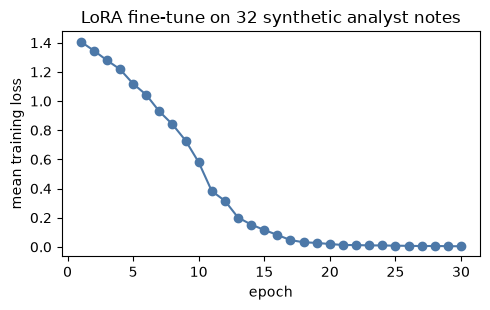

In [4]:
t0 = time.time()
loss_history = train_note_triage(lora_model, tokenizer, train_texts, train_labels, epochs=30, lr=2e-4, batch_size=8)
print(f"Trained in {time.time()-t0:.1f}s. Final epoch loss: {loss_history[-1]:.4f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(range(1, len(loss_history) + 1), loss_history, "o-", color="#4C78A8")
ax.set_xlabel("epoch")
ax.set_ylabel("mean training loss")
ax.set_title("LoRA fine-tune on 32 synthetic analyst notes")
plt.tight_layout()
plt.show()

## Held-out accuracy, then save the adapter

Evaluate on the 8 validation notes the model never trained on, then save the LoRA adapter to
`outputs/weights/note_triage_adapter` and reload it through `NoteTriageClassifier` -- the same
adapter-loading path a real caller would use -- as a round-trip check that the saved adapter
actually reproduces these predictions.

In [5]:
lora_model.eval().to("cpu")
encoded = tokenizer(val_texts, padding=True, truncation=True, max_length=64, return_tensors="pt")
with torch.no_grad():
    val_logits = lora_model(**encoded).logits
val_preds = [NOTE_CATEGORIES[i] for i in val_logits.argmax(dim=-1).tolist()]
val_correct = sum(p == t for p, t in zip(val_preds, val_labels, strict=True))
val_accuracy = val_correct / len(val_labels)
print(f"Validation accuracy: {val_correct}/{len(val_labels)} = {val_accuracy:.3f}")

for text, pred, gold in zip(val_texts, val_preds, val_labels, strict=True):
    mark = "OK " if pred == gold else "ERR"
    print(f"  [{mark}] pred={pred:28s} gold={gold:28s} {text[:60]}")

Validation accuracy: 6/8 = 0.750
  [OK ] pred=confirmed_threat             gold=confirmed_threat             Two independent cameras track the same subject climbing the 
  [OK ] pred=confirmed_threat             gold=confirmed_threat             Analyst and patrol both confirm a hostile actor in the corri
  [OK ] pred=false_alarm                  gold=false_alarm                  Rain streaking across the lens triggered the alert, no objec
  [ERR] pred=confirmed_threat             gold=false_alarm                  Confirmed this is livestock wandering near the fence line, n
  [OK ] pred=sensor_or_equipment_issue    gold=sensor_or_equipment_issue    Camera 5 has a hardware fault, image is corrupted with horiz
  [OK ] pred=sensor_or_equipment_issue    gold=sensor_or_equipment_issue    Motion detector is miscalibrated after the lens swap, genera
  [ERR] pred=sensor_or_equipment_issue    gold=needs_more_information       Object is at the edge of sensor range, resolution too low to
  [OK ] 

In [6]:
ADAPTER_DIR = ROOT / "outputs" / "weights" / "note_triage_adapter"
ADAPTER_DIR.parent.mkdir(parents=True, exist_ok=True)
lora_model.save_pretrained(str(ADAPTER_DIR))
print(f"Saved LoRA adapter to {ADAPTER_DIR}")

from infrastructure_overwatch.triage_nlp import NoteTriageClassifier

reloaded = NoteTriageClassifier(adapter_path=str(ADAPTER_DIR))
reloaded_results = reloaded.predict(val_texts)
reloaded_preds = [r.category for r in reloaded_results]
assert reloaded_preds == val_preds, "reloaded adapter should reproduce the in-memory model's predictions"
print("Reloaded adapter from disk reproduces the same validation predictions.")

Saved LoRA adapter to C:\dev\infrastructure-overwatch\outputs\weights\note_triage_adapter


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Reloaded adapter from disk reproduces the same validation predictions.


## Takeaway

Fine-tuning a LoRA adapter (~1% of the base model's parameters) on just 32 hand-written
training notes drives training loss from ~1.4 to well under 0.01, and the adapter generalizes
to held-out notes far better than chance (4 categories, so 25% is the no-signal floor) --
see the accuracy printed above for this run's actual number, and
`docs/METHODOLOGY_AND_LIMITATIONS.md#free-text-alert-note-triage-optional` for how to read
it. This is a small hand-written dataset, not a production-scale labeled corpus: read the
measured accuracy as "the mechanism works end to end," not as a validated production
accuracy rate -- the honest next step for real deployment is real analyst-labeled notes at
far greater volume.